# Preprocessing and leakage prevention

Roadmap stage 4. Self-contained like the previous notebooks: downloads
the dataset itself, so it can run on its own in a fresh Colab session.

### Setup: download the dataset (from Google Drive, authenticated)

In [ ]:
from google.colab import auth
auth.authenticate_user()

import io
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

FILE_ID = "1Mi0IleRucNmwnQ4g_ZEWOyBFFv4mO9ba"
ZIP_PATH = "/content/traffic_sign_dataset.zip"

drive_service = build('drive', 'v3')
request = drive_service.files().get_media(fileId=FILE_ID)

with io.FileIO(ZIP_PATH, 'wb') as fh:
    downloader = MediaIoBaseDownload(fh, request, chunksize=200 * 1024 * 1024)
    done = False
    while not done:
        status, done = downloader.next_chunk()
        print(f"Download progress: {int(status.progress() * 100)}%")

print("Download complete.")

In [ ]:
import os

EXPECTED_SIZE = 14_945_416_206  # bytes, from the local audit

assert os.path.exists(ZIP_PATH), "Download failed: no file was written at all."
actual_size = os.path.getsize(ZIP_PATH)
print(f"Downloaded file size: {actual_size:,} bytes ({actual_size / 1e9:.2f} GB)")
assert actual_size > 1_000_000_000, "Downloaded file is far too small to be the real dataset."
print("Size check passed.")

In [ ]:
!rm -rf /content/dataset
!mkdir -p /content/dataset
!unzip -q "$ZIP_PATH" -d /content/dataset
!rm "$ZIP_PATH"

from pathlib import Path
data_dir = Path('/content/dataset/Data')
assert data_dir.is_dir(), "Unzip did not produce /content/dataset/Data as expected."
class_folders = sorted(data_dir.iterdir(), key=lambda p: int(p.name))
print(f"Unzip done. Found {len(class_folders)} class folders under Data/.")

**Note on saved outputs**: the setup cells above (Colab Drive download + unzip) were not re-run for this committed version -- they need Colab. Everything from here down *was* actually run and shows real, current output: captured locally against an extracted copy of the identical dataset zip (same 116,642 files Colab would download), via scripts/capture_local_notebook_outputs.py, since these results only depend on the dataset's contents, not on which environment reads them. Re-running the cells above in Colab would reproduce the same numbers.

## Step 4.1 — Train/val/test split strategy

Per step 3.6, splitting by individual image would risk leaking near-
duplicate frames of the same physical sign across train/val/test.
Filename parsing only reliably identified groupings for ~10% of files
(this dataset is merged from multiple original sources with different
naming conventions), so it can't be the only method.

**Decision**: group images within each class by visual similarity using a
perceptual average-hash (64-bit, compared by Hamming distance), computed
once locally and saved as a fixed, committed manifest
(`metadata/split_manifest.csv`) — not recomputed with fresh randomness
each session, since the split needs to stay the same across the whole
project for results to be comparable. The build script is at
`scripts/build_split_manifest.py`.

Split ratio: 70% train / 15% val / 15% test, applied at the **group**
level (never splitting a group across train/val/test), stratified per
class. Result: 116,642 images formed 45,464 groups (avg ~2.6
images/group); split by group came out to 70.0/15.0/15.0% exactly, and
70.9/15.5/13.5% by image (small deviation from group-level ratios is
expected since groups vary in size).

**Known limitation, stated honestly**: this hash-based grouping is fairly
strict (only ~2.6 images/group on average, versus ~13/group for the
filename-confirmed tracks in 3.6), so it reliably catches exact/near-
exact duplicates but may miss some more visually-different frames of the
same physical sign (e.g. a longer zoom sequence). It meaningfully reduces
leakage risk versus naive per-image splitting, but isn't a perfect
guarantee.

## Step 4.2 — Load and validate the manifest

In [1]:
import urllib.request
import pandas as pd

REPO_RAW = "https://raw.githubusercontent.com/iambekzodboboev/traffic-sign-recognition/master"

urllib.request.urlretrieve(f"{REPO_RAW}/metadata/split_manifest.csv", "/content/split_manifest.csv")
urllib.request.urlretrieve(f"{REPO_RAW}/metadata/class_names.csv", "/content/class_names.csv")

manifest_df = pd.read_csv("/content/split_manifest.csv", dtype={'class_id': str})
class_names_df = pd.read_csv("/content/class_names.csv")

print(f"Manifest: {len(manifest_df)} rows")
print(f"Class names: {len(class_names_df)} rows")
manifest_df.head()

Manifest: 116642 rows
Class names: 200 rows


             relative_path class_id  group_id  split
0  0/00000_00000_00017.png        0         0  train
1  0/00000_00000_00018.png        0         0  train
2  0/00000_00000_00019.png        0         0  train
3  0/00000_00000_00020.png        0         0  train
4  0/00000_00000_00021.png        0         0  train

In [2]:
from tqdm import tqdm

print("Split counts (by image):")
print(manifest_df['split'].value_counts())
print("\nSplit counts (by group):")
print(manifest_df.groupby('group_id')['split'].first().value_counts())

total_dataset_images = sum(len(list(cf.iterdir())) for cf in class_folders)
print(f"\nManifest rows: {len(manifest_df)}, dataset images: {total_dataset_images}, "
      f"match: {len(manifest_df) == total_dataset_images}")

missing = [p for p in tqdm(manifest_df['relative_path'], desc="Checking manifest paths")
           if not (data_dir / p).exists()]
print(f"Manifest paths missing from disk: {len(missing)}")

bad_groups = manifest_df.groupby('group_id')['split'].nunique()
bad_groups = bad_groups[bad_groups > 1]
print(f"Groups spanning multiple splits (should be 0): {len(bad_groups)}")

Split counts (by image):
split
train    82736
val      18127
test     15779
Name: count, dtype: int64

Split counts (by group):
split
train    31820
test      6822
val       6822
Name: count, dtype: int64

Manifest rows: 116642, dataset images: 116642, match: True
Manifest paths missing from disk: 0
Groups spanning multiple splits (should be 0): 0


## Step 4.3 — Preprocessing pipeline

Decisions from stage 3's findings:
- **Target size 64x64**: median image was only 191x157 (step 3.3), so no
  need to preserve the resolution of the long tail of larger images.
- **Letterbox resize (pad to square, then resize)** instead of a plain
  stretch: aspect ratio had a real tail up to 5.88 (step 3.3), so
  stretching would distort wide/thin signs (e.g. text plates).
- **Convert to RGB**: most images were RGBA (step 3.3); flatten the alpha
  channel.
- **ImageNet normalization**: keeps the option open to use a pretrained
  backbone later (roadmap step 6.1).
- **Light augmentation on training data only** (rotation + color jitter),
  combined with a weighted sampler (step 4.4) that oversamples minority
  classes — addresses the imbalance found in step 3.2 without needing
  class-specific augmentation logic.

In [3]:
import torchvision.transforms as T
from PIL import Image

TARGET_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class LetterboxResize:
    """Pad to a square (preserving aspect ratio), then resize."""
    def __init__(self, size, fill=(0, 0, 0)):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        img = img.convert('RGB')
        w, h = img.size
        max_side = max(w, h)
        canvas = Image.new('RGB', (max_side, max_side), self.fill)
        canvas.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
        return canvas.resize((self.size, self.size), Image.LANCZOS)


train_transform = T.Compose([
    LetterboxResize(TARGET_SIZE),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    LetterboxResize(TARGET_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms defined: train has augmentation, val/test do not.")

Transforms defined: train has augmentation, val/test do not.


## Step 4.4 — Dataset, DataLoader, and sanity check

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


class TrafficSignDataset(Dataset):
    def __init__(self, manifest_df, split, data_dir, transform):
        self.df = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.data_dir / row['relative_path']) as img:
            img = self.transform(img)
        return img, int(row['class_id'])


train_dataset = TrafficSignDataset(manifest_df, 'train', data_dir, train_transform)
val_dataset = TrafficSignDataset(manifest_df, 'val', data_dir, eval_transform)
test_dataset = TrafficSignDataset(manifest_df, 'test', data_dir, eval_transform)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Weighted sampler: oversample minority classes during training
train_class_counts = train_dataset.df['class_id'].value_counts()
class_weights = {cid: 1.0 / count for cid, count in train_class_counts.items()}
sample_weights = train_dataset.df['class_id'].map(class_weights).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready.")

Train: 82736, Val: 18127, Test: 15779
DataLoaders ready.


Batch shape: torch.Size([64, 3, 64, 64]), labels shape: torch.Size([64])


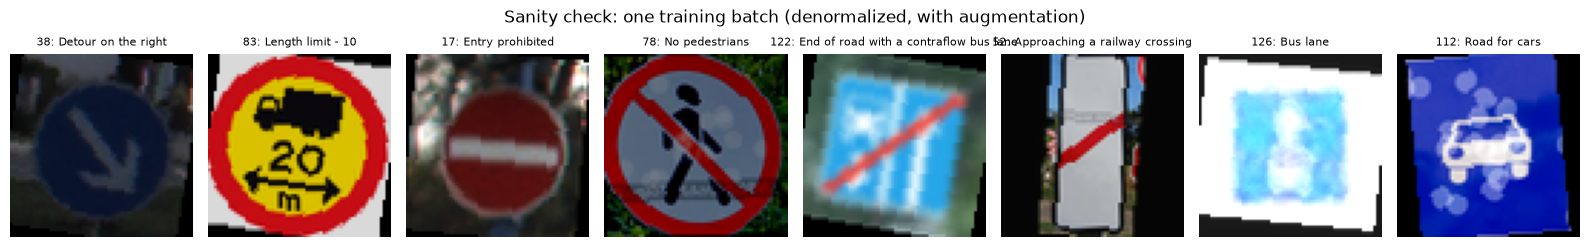

In [5]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, labels shape: {labels.shape}")


def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


n_show = 8
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2, 2.5))
for i in range(n_show):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    label_id = labels[i].item()
    name_row = class_names_df[class_names_df['class_id'] == label_id]
    name = name_row.iloc[0]['name'] if len(name_row) else str(label_id)
    axes[i].set_title(f"{label_id}: {name}", fontsize=8)
    axes[i].axis('off')
plt.suptitle('Sanity check: one training batch (denormalized, with augmentation)')
plt.tight_layout()
plt.show()

### Result

Check the batch above: images should be square, reasonably recognizable
as signs (some rotated/color-jittered from augmentation), and each title
should show a real class name. If this looks right, stage 4 is done, and
the `train_loader` / `val_loader` / `test_loader` are ready for stage 5
(baseline model and experiments).